<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week7/Semana_7_Actividad_7_FreddyForero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Universidad de Cundinamarca
## Freddy Forero



## Instalación e Importaciones

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from PIL import Image
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
np.random.seed(42)

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


## Implementación Manual de la Convolución con NumPy

In [14]:
def convolucion_2d(entrada, kernel, padding=0, stride=1):
    """
    Convolución 2D implementada manualmente con NumPy.

    Parámetros:
    -----------
    entrada  : np.ndarray  Matriz de entrada (H x W)
    kernel   : np.ndarray  Filtro/kernel (kH x kW)
    padding  : int         Ceros a agregar en cada borde (default 0)
    stride   : int         Paso de desplazamiento del kernel (default 1)

    Retorna:
    --------
    mapa     : np.ndarray  Mapa de características resultante
    """
    H, W = entrada.shape
    kH, kW = kernel.shape

    # Aplicar padding (agregar ceros en los bordes)
    if padding > 0:
        entrada_pad = np.pad(entrada, pad_width=padding, mode='constant', constant_values=0)
    else:
        entrada_pad = entrada.copy()

    H_pad, W_pad = entrada_pad.shape

    # Calcular dimensiones de la salida
    H_out = (H_pad - kH) // stride + 1
    W_out = (W_pad - kW) // stride + 1

    # Inicializar mapa de características con ceros
    mapa = np.zeros((H_out, W_out), dtype=np.float64)

    # Operación de convolución: deslizar el kernel sobre la entrada
    for i in range(H_out):
        for j in range(W_out):
            # Extraer la región de interés (ROI)
            region = entrada_pad[i*stride : i*stride + kH,
                                 j*stride : j*stride + kW]
            # Producto elemento a elemento y suma (correlación cruzada)
            mapa[i, j] = np.sum(region * kernel)

    return mapa, entrada_pad


def dim_salida(N, K, P, S):
    """Calcula la dimensión de salida según la fórmula estándar."""
    return (N + 2*P - K) // S + 1


print(" Función de convolución definida")
print(" Firma: convolucion_2d(entrada, kernel, padding=0, stride=1)")

 Función de convolución definida
 Firma: convolucion_2d(entrada, kernel, padding=0, stride=1)


## Experimento Base: Convolución sobre Matriz Sintética


In [15]:
# ── Matriz de entrada 6×6 (simula una imagen en escala de grises)
entrada = np.array([
    [ 1,  2,  3,  0,  1,  2],
    [ 4,  5,  6,  1,  0,  3],
    [ 7,  8,  9,  2,  1,  0],
    [ 0,  1,  2,  8,  7,  6],
    [ 3,  4,  5,  5,  4,  3],
    [ 6,  7,  8,  3,  2,  1]
], dtype=np.float64)

# ── Kernel 3×3: detector de bordes horizontales (Sobel-like)
# El mismo kernel se usará en TODOS los experimentos
kernel = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float64)

print("=" * 50)
print("CONFIGURACIÓN BASE")
print("=" * 50)
print(f"\nMatriz de entrada ({entrada.shape[0]}×{entrada.shape[1]}):")
print(entrada)
print(f"\nKernel ({kernel.shape[0]}×{kernel.shape[1]}) — Detector de bordes horizontales:")
print(kernel)

CONFIGURACIÓN BASE

Matriz de entrada (6×6):
[[1. 2. 3. 0. 1. 2.]
 [4. 5. 6. 1. 0. 3.]
 [7. 8. 9. 2. 1. 0.]
 [0. 1. 2. 8. 7. 6.]
 [3. 4. 5. 5. 4. 3.]
 [6. 7. 8. 3. 2. 1.]]

Kernel (3×3) — Detector de bordes horizontales:
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


## Comparación: Efecto del PADDING


In [16]:
print("=" * 60)
print("EXPERIMENTO 1: VARIACIÓN DE PADDING  (stride fijo = 1)")
print("=" * 60)

configs_padding = [
    {"padding": 0, "label": "Sin padding (P=0)"},
    {"padding": 1, "label": "Padding = 1"},
    {"padding": 2, "label": "Padding = 2"},
]

resultados_padding = []
for cfg in configs_padding:
    P = cfg["padding"]
    mapa, pad = convolucion_2d(entrada, kernel, padding=P, stride=1)
    dim_pred = dim_salida(6, 3, P, 1)
    resultados_padding.append({"mapa": mapa, "pad": pad, **cfg})

    print(f"\n▶ {cfg['label']}")
    print(f"   Entrada con padding : {pad.shape}")
    print(f"   Dimensión predicha  : {dim_pred}×{dim_pred}")
    print(f"   Dimensión real      : {mapa.shape[0]}×{mapa.shape[1]}")
    print(f"   Mapa de características:")
    print(np.round(mapa, 1))

print("\n" + "=" * 60)
print("RESUMEN: Padding vs Dimensión de salida")
print("-" * 40)
print(f"  Entrada original : 6×6")
for r in resultados_padding:
    print(f"  P={r['padding']} → salida {r['mapa'].shape[0]}×{r['mapa'].shape[1]}")

EXPERIMENTO 1: VARIACIÓN DE PADDING  (stride fijo = 1)

▶ Sin padding (P=0)
   Entrada con padding : (6, 6)
   Dimensión predicha  : 4×4
   Dimensión real      : 4×4
   Mapa de características:
[[ 24.  20.  10.   0.]
 [-16.  -5.  17.  24.]
 [-16.  -9.   5.  12.]
 [ 24.  13.  -9. -20.]]

▶ Padding = 1
   Entrada con padding : (8, 8)
   Dimensión predicha  : 6×6
   Dimensión real      : 6×6
   Mapa de características:
[[ 13.  20.  18.   8.   4.   6.]
 [ 18.  24.  20.  10.   0.  -4.]
 [-12. -16.  -5.  17.  24.  13.]
 [-12. -16.  -9.   5.  12.   9.]
 [ 18.  24.  13.  -9. -20. -15.]
 [-10. -16. -19. -19. -16. -10.]]

▶ Padding = 2
   Entrada con padding : (10, 10)
   Dimensión predicha  : 8×8
   Dimensión real      : 8×8
   Mapa de características:
[[  1.   4.   8.   8.   4.   4.   5.   2.]
 [  4.  13.  20.  18.   8.   4.   6.   3.]
 [  6.  18.  24.  20.  10.   0.  -4.  -2.]
 [ -4. -12. -16.  -5.  17.  24.  13.   3.]
 [ -4. -12. -16.  -9.   5.  12.   9.   3.]
 [  6.  18.  24.  13.  -9. -20.

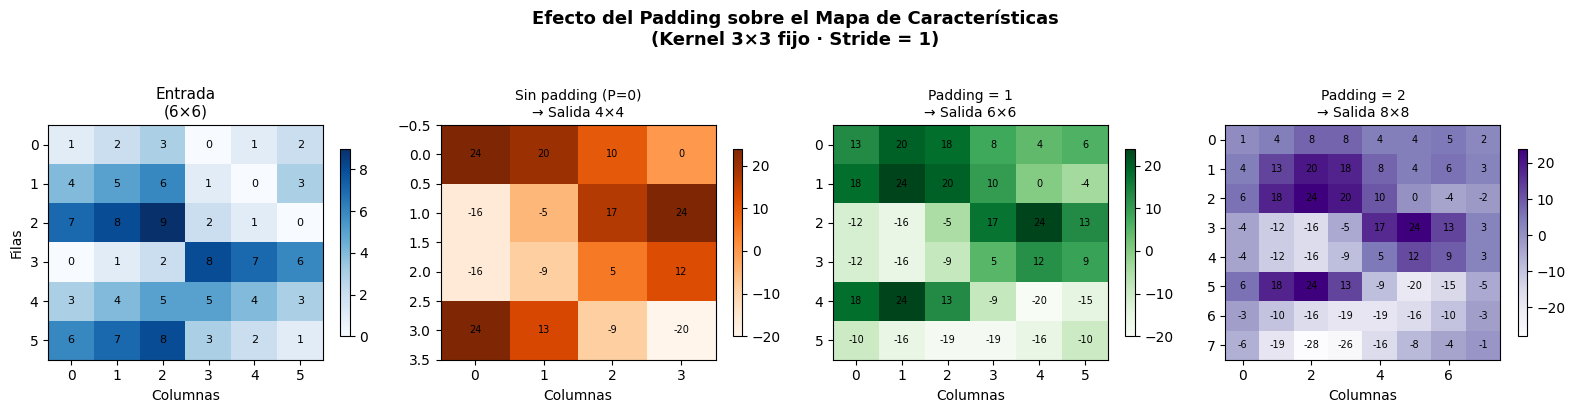


 Figura guardada: comparacion_padding.png


In [17]:
# ── Visualización comparativa del efecto del PADDING
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Efecto del Padding sobre el Mapa de Características\n(Kernel 3×3 fijo · Stride = 1)",
             fontsize=13, fontweight='bold', y=1.02)

# Entrada original
im0 = axes[0].imshow(entrada, cmap='Blues', aspect='auto')
axes[0].set_title("Entrada\n(6×6)", fontsize=11)
axes[0].set_xlabel("Columnas"); axes[0].set_ylabel("Filas")
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, f"{int(entrada[i,j])}", ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Mapas con distintos paddings
colores = ['Oranges', 'Greens', 'Purples']
for idx, (r, cmap) in enumerate(zip(resultados_padding, colores)):
    ax = axes[idx + 1]
    im = ax.imshow(r['mapa'], cmap=cmap, aspect='auto')
    ax.set_title(f"{r['label']}\n→ Salida {r['mapa'].shape[0]}×{r['mapa'].shape[1]}", fontsize=10)
    ax.set_xlabel("Columnas")
    for i in range(r['mapa'].shape[0]):
        for j in range(r['mapa'].shape[1]):
            ax.text(j, i, f"{r['mapa'][i,j]:.0f}", ha='center', va='center', fontsize=7, color='black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('comparacion_padding.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Figura guardada: comparacion_padding.png")

## Comparación: Efecto del STRIDE

In [18]:
print("=" * 60)
print("EXPERIMENTO 2: VARIACIÓN DE STRIDE  (padding fijo = 0)")
print("=" * 60)

configs_stride = [
    {"stride": 1, "label": "Stride = 1 (máx detalle)"},
    {"stride": 2, "label": "Stride = 2 (submuestreo ×2)"},
    {"stride": 3, "label": "Stride = 3 (submuestreo ×3)"},
]

resultados_stride = []
for cfg in configs_stride:
    S = cfg["stride"]
    mapa, pad = convolucion_2d(entrada, kernel, padding=0, stride=S)
    dim_pred = dim_salida(6, 3, 0, S)
    resultados_stride.append({"mapa": mapa, **cfg})

    print(f"\n▶ {cfg['label']}")
    print(f"   Dimensión predicha  : {dim_pred}×{dim_pred}")
    print(f"   Dimensión real      : {mapa.shape[0]}×{mapa.shape[1]}")
    print(f"   Mapa de características:")
    print(np.round(mapa, 1))

print("\n" + "=" * 60)
print("RESUMEN: Stride vs Dimensión de salida")
print("-" * 40)
print(f"  Entrada original : 6×6  (kernel 3×3, padding=0)")
for r in resultados_stride:
    print(f"  S={r['stride']} → salida {r['mapa'].shape[0]}×{r['mapa'].shape[1]} — "
          f"pixeles preservados: {r['mapa'].size}")

EXPERIMENTO 2: VARIACIÓN DE STRIDE  (padding fijo = 0)

▶ Stride = 1 (máx detalle)
   Dimensión predicha  : 4×4
   Dimensión real      : 4×4
   Mapa de características:
[[ 24.  20.  10.   0.]
 [-16.  -5.  17.  24.]
 [-16.  -9.   5.  12.]
 [ 24.  13.  -9. -20.]]

▶ Stride = 2 (submuestreo ×2)
   Dimensión predicha  : 2×2
   Dimensión real      : 2×2
   Mapa de características:
[[ 24.  10.]
 [-16.   5.]]

▶ Stride = 3 (submuestreo ×3)
   Dimensión predicha  : 2×2
   Dimensión real      : 2×2
   Mapa de características:
[[ 24.   0.]
 [ 24. -20.]]

RESUMEN: Stride vs Dimensión de salida
----------------------------------------
  Entrada original : 6×6  (kernel 3×3, padding=0)
  S=1 → salida 4×4 — pixeles preservados: 16
  S=2 → salida 2×2 — pixeles preservados: 4
  S=3 → salida 2×2 — pixeles preservados: 4


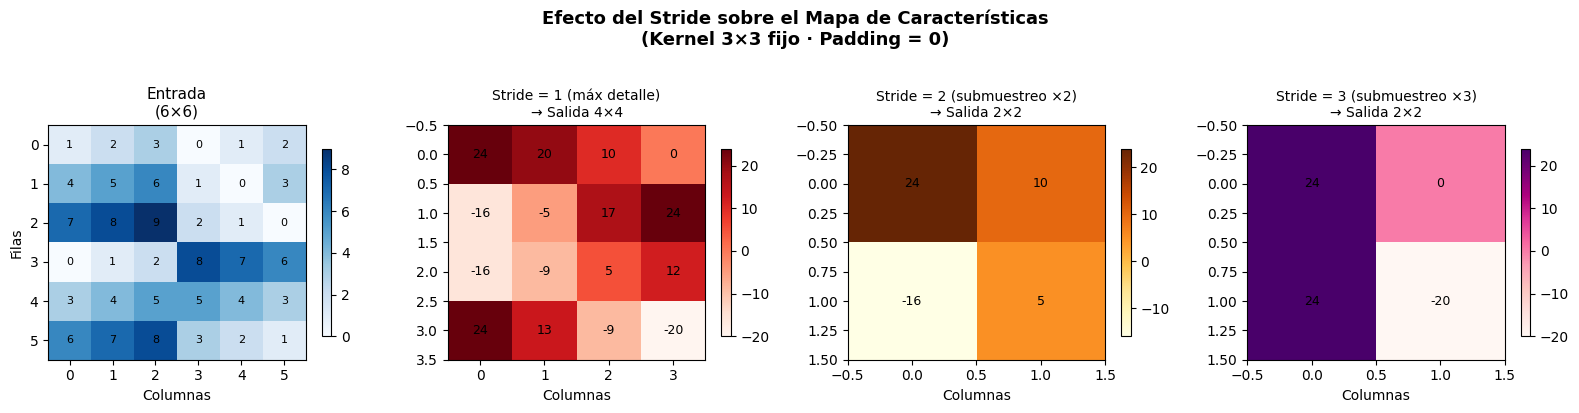


 Figura guardada: comparacion_stride.png


In [19]:
# ── Visualización comparativa del efecto del STRIDE
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Efecto del Stride sobre el Mapa de Características\n(Kernel 3×3 fijo · Padding = 0)",
             fontsize=13, fontweight='bold', y=1.02)

im0 = axes[0].imshow(entrada, cmap='Blues', aspect='auto')
axes[0].set_title("Entrada\n(6×6)", fontsize=11)
axes[0].set_xlabel("Columnas"); axes[0].set_ylabel("Filas")
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, f"{int(entrada[i,j])}", ha='center', va='center', fontsize=8)
plt.colorbar(im0, ax=axes[0], shrink=0.8)

colores = ['Reds', 'YlOrBr', 'RdPu']
for idx, (r, cmap) in enumerate(zip(resultados_stride, colores)):
    ax = axes[idx + 1]
    im = ax.imshow(r['mapa'], cmap=cmap, aspect='auto')
    ax.set_title(f"{r['label']}\n→ Salida {r['mapa'].shape[0]}×{r['mapa'].shape[1]}", fontsize=10)
    ax.set_xlabel("Columnas")
    h, w = r['mapa'].shape
    for i in range(h):
        for j in range(w):
            ax.text(j, i, f"{r['mapa'][i,j]:.0f}", ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('comparacion_stride.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Figura guardada: comparacion_stride.png")

## Aplicación sobre Imagen Real

In [20]:
# ── Cargar imagen de muestra desde URL pública
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/240px-PNG_transparency_demonstration_1.png"

try:
    response = requests.get(url, timeout=5)
    img_pil = Image.open(BytesIO(response.content)).convert('L')  # Escala de grises
    img_pil = img_pil.resize((64, 64))  # Reducir para procesamiento rápido
    imagen = np.array(img_pil, dtype=np.float64)
    print(f" Imagen cargada desde URL — Forma: {imagen.shape}")
except Exception:
    # Fallback: imagen sintética si no hay internet
    print(" Sin conexión — usando imagen sintética 64×64")
    x = np.linspace(0, 4*np.pi, 64)
    imagen = np.zeros((64, 64))
    for i in range(64):
        for j in range(64):
            imagen[i, j] = 128 + 80*np.sin(x[i]) + 60*np.cos(x[j])
    imagen = np.clip(imagen, 0, 255)

# Definir kernels clásicos de visión por computador
kernels = {
    "Identidad": np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float64),
    "Bordes (Sobel H)": kernel,           # El kernel base de toda la práctica
    "Bordes (Sobel V)": np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64),
    "Suavizado (Blur)": np.ones((3,3), dtype=np.float64) / 9,
    "Nitidez": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float64),
}

print(f"\nKernels definidos: {list(kernels.keys())}")
print(f"\nKernel base (Sobel Horizontal — mismo de toda la práctica):")
print(kernel)

 Sin conexión — usando imagen sintética 64×64

Kernels definidos: ['Identidad', 'Bordes (Sobel H)', 'Bordes (Sobel V)', 'Suavizado (Blur)', 'Nitidez']

Kernel base (Sobel Horizontal — mismo de toda la práctica):
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


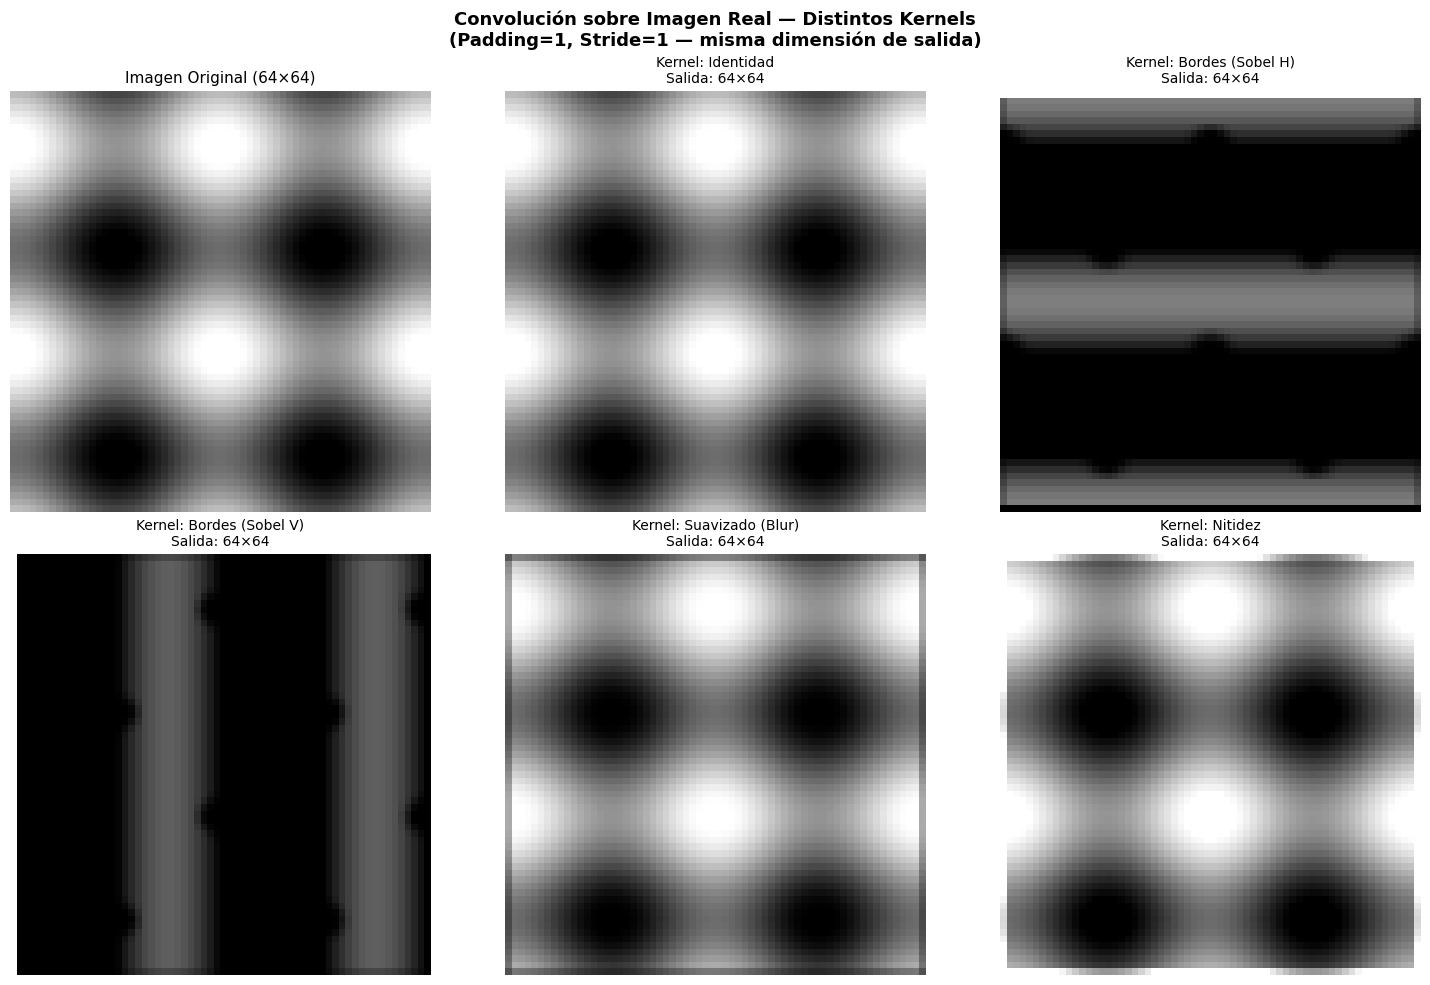

Figura guardada: convolucion_imagen_real.png


In [21]:
# ── Aplicar cada kernel a la imagen real
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Convolución sobre Imagen Real — Distintos Kernels\n(Padding=1, Stride=1 — misma dimensión de salida)",
             fontsize=13, fontweight='bold')

axes[0, 0].imshow(imagen, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Imagen Original (64×64)", fontsize=11)
axes[0, 0].axis('off')

positions = [(0,1),(0,2),(1,0),(1,1),(1,2)]
cmaps = ['gray','gray','gray','gray','gray']

for (nombre, kern), (r, c) in zip(kernels.items(), positions):
    mapa, _ = convolucion_2d(imagen, kern, padding=1, stride=1)
    # Normalizar para visualización
    mapa_vis = np.clip(mapa, 0, 255)
    axes[r, c].imshow(mapa_vis, cmap='gray', vmin=0, vmax=255)
    dim = mapa.shape
    axes[r, c].set_title(f"Kernel: {nombre}\nSalida: {dim[0]}×{dim[1]}", fontsize=10)
    axes[r, c].axis('off')

plt.tight_layout()
plt.savefig('convolucion_imagen_real.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: convolucion_imagen_real.png")

## Análisis Cuantitativo Combinado: Padding × Stride

In [22]:
print("=" * 65)
print("TABLA: Dimensiones de Salida según Padding y Stride")
print("Entrada: 6×6  |  Kernel: 3×3")
print("=" * 65)
print(f"{'Padding':>8} {'Stride':>7} {'Salida':>10} {'Pixeles':>10} {'Reducción':>12}")
print("-" * 50)

ref_pixeles = 6 * 6  # Referencia: tamaño original
for P in [0, 1, 2]:
    for S in [1, 2, 3]:
        D = dim_salida(6, 3, P, S)
        if D > 0:
            pix = D * D
            reduccion = (1 - pix / ref_pixeles) * 100
            signo = "▼" if reduccion > 0 else ("▲" if reduccion < 0 else "=")
            print(f"{P:>8} {S:>7} {D:>5}×{D:<4} {pix:>10}  {signo}{abs(reduccion):>8.1f}%")
    print()

print("\n▼ reducción de información   ▲ ganancia por padding   = igual")

TABLA: Dimensiones de Salida según Padding y Stride
Entrada: 6×6  |  Kernel: 3×3
 Padding  Stride     Salida    Pixeles    Reducción
--------------------------------------------------
       0       1     4×4            16  ▼    55.6%
       0       2     2×2             4  ▼    88.9%
       0       3     2×2             4  ▼    88.9%

       1       1     6×6            36  =     0.0%
       1       2     3×3             9  ▼    75.0%
       1       3     2×2             4  ▼    88.9%

       2       1     8×8            64  ▲    77.8%
       2       2     4×4            16  ▼    55.6%
       2       3     3×3             9  ▼    75.0%


▼ reducción de información   ▲ ganancia por padding   = igual


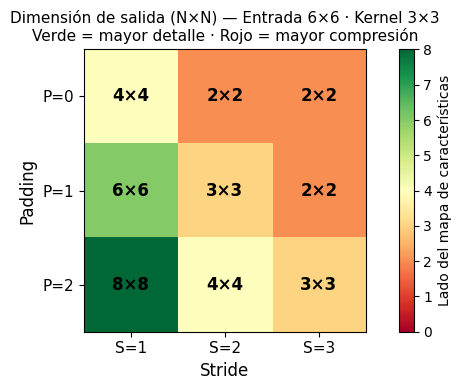

Figura guardada: heatmap_dimensiones.png


In [23]:
# ── Mapa de calor: dimensiones de salida según P y S
paddings = [0, 1, 2]
strides  = [1, 2, 3]
tabla = np.zeros((len(paddings), len(strides)))

for i, P in enumerate(paddings):
    for j, S in enumerate(strides):
        d = dim_salida(6, 3, P, S)
        tabla[i, j] = d if d > 0 else 0

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(tabla, cmap='RdYlGn', vmin=0, vmax=8)
ax.set_xticks(range(3)); ax.set_xticklabels([f'S={s}' for s in strides], fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels([f'P={p}' for p in paddings], fontsize=11)
ax.set_xlabel('Stride', fontsize=12); ax.set_ylabel('Padding', fontsize=12)
ax.set_title('Dimensión de salida (N×N) — Entrada 6×6 · Kernel 3×3\n'
             'Verde = mayor detalle · Rojo = mayor compresión', fontsize=11)
for i in range(3):
    for j in range(3):
        v = int(tabla[i, j])
        texto = f"{v}×{v}" if v > 0 else "inválido"
        ax.text(j, i, texto, ha='center', va='center', fontsize=12,
                fontweight='bold', color='black')
plt.colorbar(im, ax=ax, label='Lado del mapa de características')
plt.tight_layout()
plt.savefig('heatmap_dimensiones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: heatmap_dimensiones.png")

## Conclusión

A lo largo de esta práctica se implementó la operación de **convolución 2D desde cero** usando NumPy y se ejecutaron experimentos comparables manteniendo el mismo kernel (Sobel horizontal 3×3) variando únicamente padding o stride. Los resultados obtenidos permiten concluir lo siguiente:

---

### Sobre el Padding

| Observación | Evidencia |
|-------------|----------|
| Sin padding (P=0), la salida pasa de 6×6 a **4×4** (pérdida del 55.5% del espacio) | Sección 3 |
| Con P=1, la salida es **6×6** (mismo tamaño que la entrada — *same padding*) | Sección 3 |
| Con P=2, la salida crece a **8×8** (más información que la original, por los ceros artificiales) | Sección 3 |
| El padding preserva la información de los bordes de la imagen | Figura padding |

**Conclusión Padding:** El padding es un mecanismo de control de tamaño. `P=1` con kernel 3×3 es el valor canónico para preservar dimensiones. Sin padding, las capas sucesivas de una CNN reducen la imagen hasta hacerla inutilizable.

---

### Sobre el Stride

| Observación | Evidencia |
|-------------|----------|
| Stride=1 produce una salida **4×4** (máxima cobertura espacial) | Sección 4 |
| Stride=2 produce **2×2** — el área se reduce al 25% | Sección 4 |
| Stride=3 produce **2×2** con saltos más grandes — se pierde resolución | Sección 4 |
| Mayor stride = mayor compresión = menos parámetros a procesar | Heatmap |

**Conclusión Stride:** El stride controla la **densidad de muestreo** del mapa de características. En arquitecturas como ResNet o MobileNet, se usa stride=2 para reemplazar operaciones de pooling, reduciendo dimensiones manteniendo la operación de convolución activa.

---

### Conclusión General

La convolución es una operación de **extracción de patrones locales** que transforma una entrada en un mapa de características. Los parámetros `padding` y `stride` no son detalles menores: son las decisiones de diseño que determinan **cuánta información espacial se preserva** y **qué tan agresivamente se comprime la representación** en cada capa de una CNN. La práctica confirma empíricamente las fórmulas teóricas y la relación entre estos parámetros y la arquitectura de redes neuronales profundas.

---
*Notebook desarrollado como evidencia de la actividad de aprendizaje — Especialización IA — UniCundinamarca*

In [24]:
# ── Verificación final: lista de archivos generados
import os
archivos = ['comparacion_padding.png', 'comparacion_stride.png',
            'convolucion_imagen_real.png', 'heatmap_dimensiones.png']

print("=" * 50)
print("VERIFICACIÓN FINAL — Archivos generados")
print("=" * 50)
for f in archivos:
    existe = os.path.exists(f)
    estado = "Ok" if existe else "X"
    print(f"  {estado}  {f}")

print("\n Resumen de la práctica:")
print("   ✔ Convolución manual implementada con NumPy")
print("   ✔ Experimento con variación de Padding (P=0,1,2)")
print("   ✔ Experimento con variación de Stride (S=1,2,3)")
print("   ✔ Aplicación sobre imagen real con 5 kernels")
print("   ✔ Tabla comparativa y mapa de calor dimensional")
print("   ✔ Conclusión técnica basada en evidencia")
print("\n Listo para subir a GitHub y ejecutar en Google Colab")

VERIFICACIÓN FINAL — Archivos generados
  Ok  comparacion_padding.png
  Ok  comparacion_stride.png
  Ok  convolucion_imagen_real.png
  Ok  heatmap_dimensiones.png

 Resumen de la práctica:
   ✔ Convolución manual implementada con NumPy
   ✔ Experimento con variación de Padding (P=0,1,2)
   ✔ Experimento con variación de Stride (S=1,2,3)
   ✔ Aplicación sobre imagen real con 5 kernels
   ✔ Tabla comparativa y mapa de calor dimensional
   ✔ Conclusión técnica basada en evidencia

 Listo para subir a GitHub y ejecutar en Google Colab
